In [52]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('AnimeWorld.csv')
df.head()

,Anime,Genre,Description,Studio,Year,Rating
0,Re:Zero kara Hajimeru Isekai Seikatsu 2nd Season,"['Drama', 'Fantasy', 'Suspense']",A reunion that was supposed to spell the arriv...,White Fox,"Jul 8, 2020",8.37
1,"Kanojo, Okarishimasu","['Comedy', 'Romance']",Kazuya Kinoshita is a 20-year-old college stud...,TMS Entertainment,"Jul 11, 2020",NaN
2,The God of High School,"['Action', 'Fantasy', 'Sci-Fi', 'Supernatural']","The ""God of High School"" tournament has begun,...",MAPPA,"Jul 6, 2020",NaN
3,Maou Gakuin no Futekigousha: Shijou Saikyou no...,"['Action', 'Fantasy']","In the distant past, a war between humans and ...",SILVER LINK.,"Jul 4, 2020",NaN
4,Enen no Shouboutai: Ni no Shou,"['Action', 'Supernatural']",After his confrontation in the Nether with his...,David Production,"Jul 4, 2020",NaN


In [ ]:
df["Year"] = pd.to_datetime(df["Year"]).dt.year

In [56]:
df["Rating"] = df["Rating"].fillna(df["Rating"].mean())

In [68]:
X = df[["Rating"]]  
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2981 entries, 0 to 2980
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Anime        2981 non-null   object 
 1   Genre        2981 non-null   object 
 2   Description  2981 non-null   object 
 3   Studio       2895 non-null   object 
 4   Year         2981 non-null   object 
 5   Rating       2981 non-null   float64
dtypes: float64(1), object(5)
memory usage: 139.9+ KB


In [69]:
wcss =[]
for i in range(1,25):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit_predict(X)
  wcss.append(kmeans.inertia_)

In [70]:
wcss

[16.195907246376827,
 7.4889845188103354,
 2.2201744434044297,
 1.2422429350278514,
 0.8403402818560164,
 0.5374288802131029,
 0.4056130072326696,
 0.37974043765276394,
 0.251616477062708,
 0.20914490026835034,
 0.17380948784152908,
 0.12822273679038124,
 0.10751226784194053,
 0.09097499960619243,
 0.08233552343693726,
 0.07258810079620737,
 0.06493699648191735,
 0.05410724869177801,
 0.0550789201086241,
 0.046335945732231265,
 0.03558347138192184,
 0.03271507702045743,
 0.03217961796681836,
 0.0287855713120058]

In [71]:
len(wcss)

24

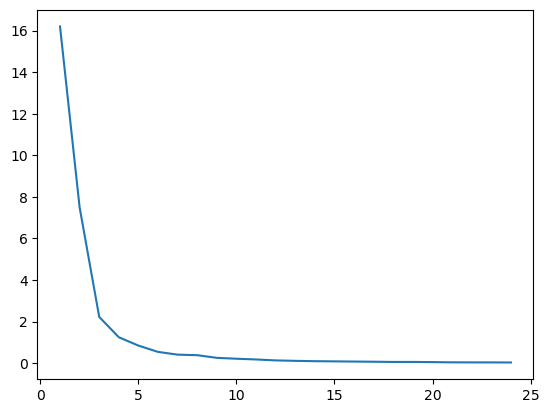

In [74]:
plt.plot(range(1,25),wcss)
plt.show()

In [99]:
model=KMeans(n_clusters=4 ,random_state=42)

In [100]:
model.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [101]:
p=model.predict(X)

In [102]:
p

array([0, 0, 0, ..., 0, 0, 0], shape=(2981,), dtype=int32)

In [103]:
from sklearn.metrics import silhouette_score
sc=silhouette_score(X,p)
sc*100

95.57514877339197